# Prediksi Kemacetan

## Pendahuluan
Pada notebook ini, kita akan membangun model prediksi untuk mendeteksi status kemacetan di jalan menggunakan metode machine learning. Model ini bertujuan untuk membantu dalam memprediksi apakah akan terjadi kemacetan berdasarkan data lalu lintas seperti kecepatan kendaraan, jumlah kendaraan, dan waktu tertentu.

## Import Library yang Dibutuhkan
Kita akan menggunakan beberapa library Python untuk melakukan analisis dan membangun model prediksi.

In [1]:

# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score


## Langkah 1: Memuat Dataset
Kita akan memuat dataset yang telah dibuat sebelumnya mengenai kondisi kemacetan lalu lintas.

In [2]:
# Load the dataset
dummy_kemacetan_df = pd.read_excel('4_prediksi_kemacetan.xlsx')
dummy_kemacetan_df

,Date,Location,Time of Day,Vehicle Count,Average Speed (km/h),Traffic Signal Status,Weather Event,Congestion Status
0,2025-01-19,Main Highway,Morning,173,72.364797,Yellow,Rain,1
1,2025-01-16,City Center,Evening,60,33.874293,Yellow,Clear,0
2,2025-02-27,Ring Road,Morning,500,76.193251,Green,Rain,1
3,2025-01-30,City Center,Evening,125,24.231954,Green,Fog,1
4,2025-02-17,Suburban Area,Evening,309,62.267818,Yellow,Wind,1
...,...,...,...,...,...,...,...,...
295,2025-01-29,Main Highway,Morning,233,38.566771,Red,Thunderstorm,0
296,2025-01-13,City Center,Morning,117,68.414948,Green,Thunderstorm,1
297,2025-02-12,City Center,Afternoon,427,37.142212,Yellow,Fog,1
298,2025-03-02,Residential Area,Morning,133,29.317854,Green,Thunderstorm,1


## Langkah 2: Preprocessing Data
Kita akan melakukan encoding pada kolom kategori, seperti 'Congestion Status' dan 'Traffic Signal Status'.

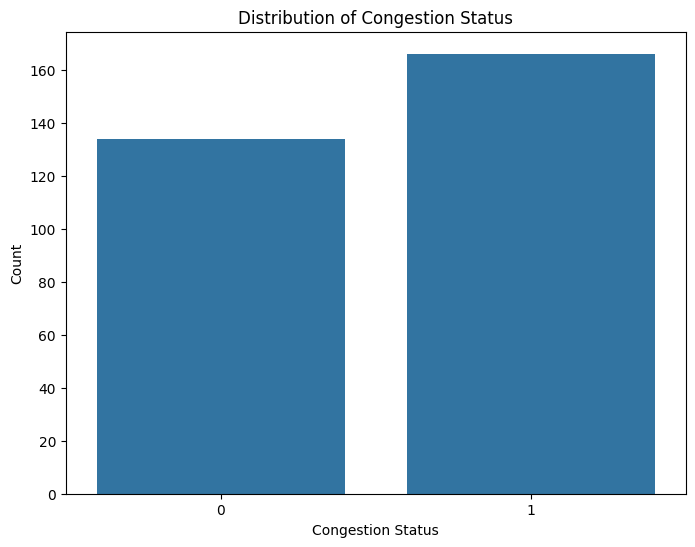

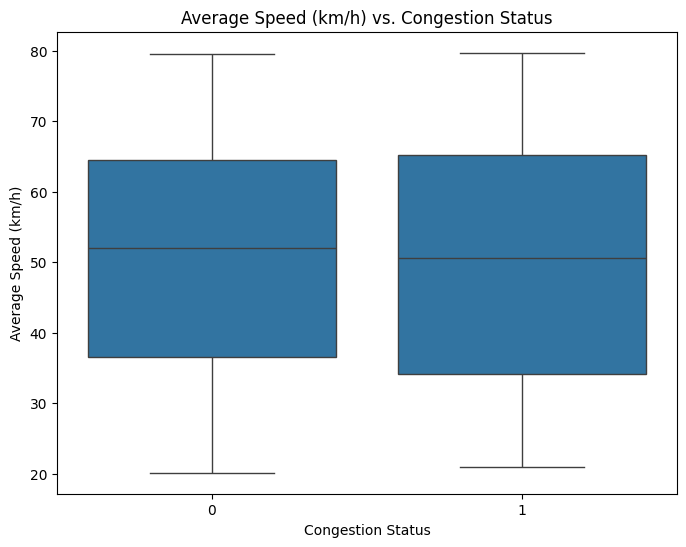

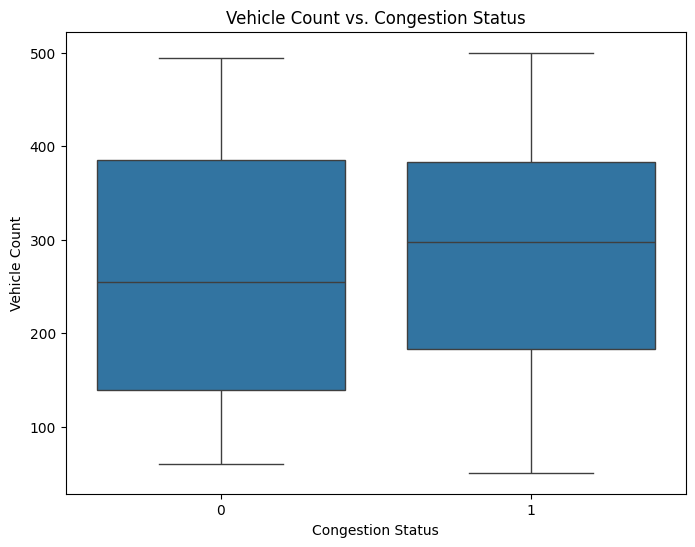

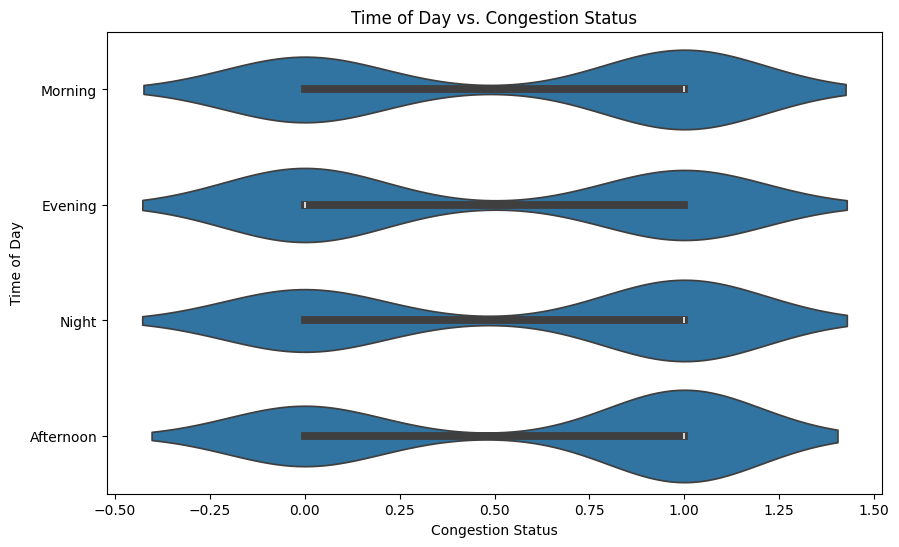

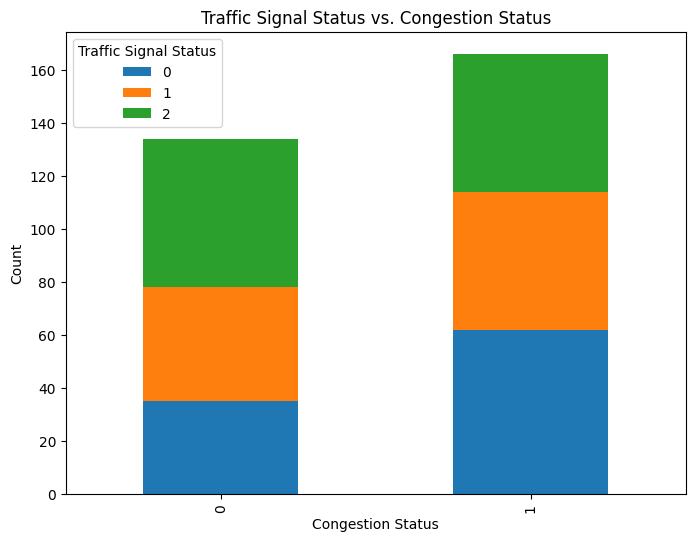

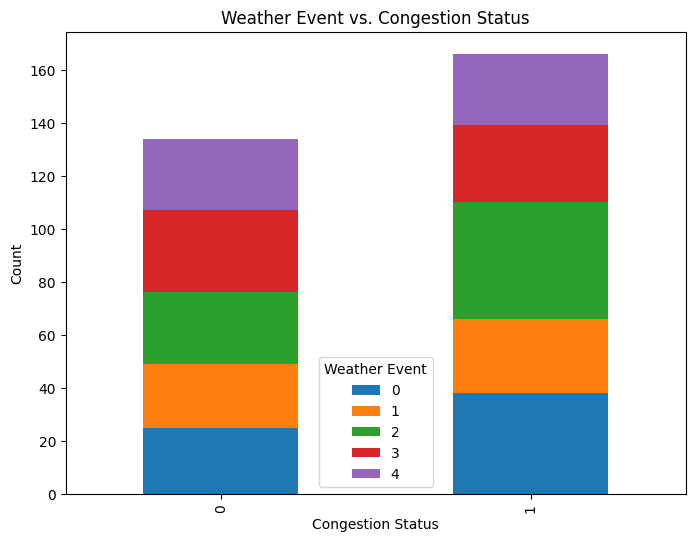

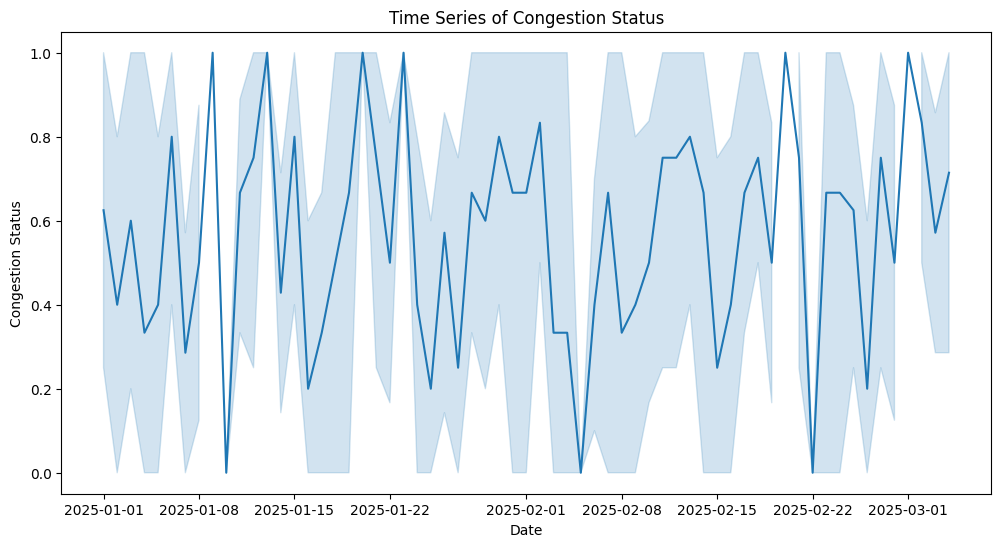

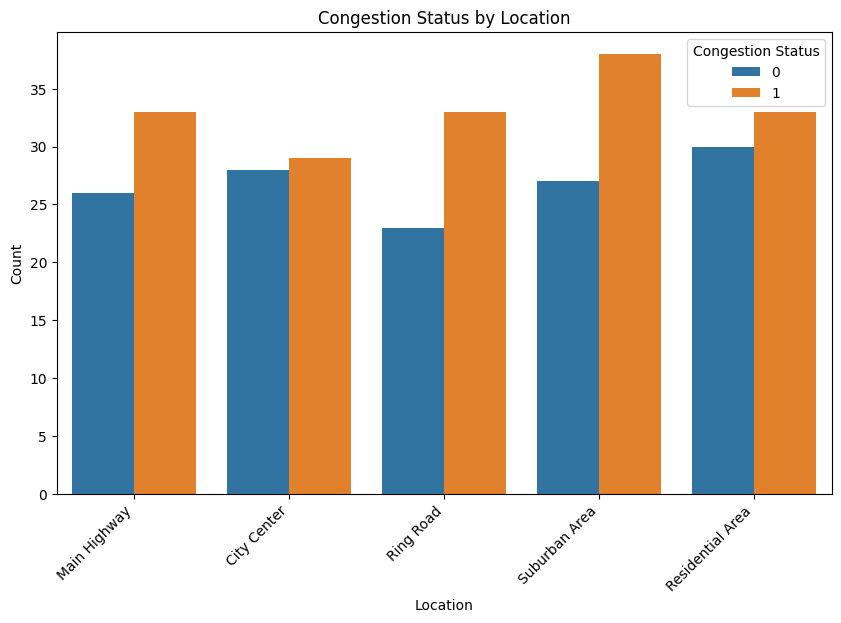

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
# Assuming 'dummy_kemacetan_df' is already loaded as shown in the provided code.

# 1. Distribution of Congestion Status (Bar Plot)
plt.figure(figsize=(8, 6))
sns.countplot(x='Congestion Status', data=dummy_kemacetan_df)
plt.title('Distribution of Congestion Status')
plt.xlabel('Congestion Status')
plt.ylabel('Count')
plt.show()

# 2. Average Speed vs. Congestion Status (Box Plot)
plt.figure(figsize=(8, 6))
sns.boxplot(x='Congestion Status', y='Average Speed (km/h)', data=dummy_kemacetan_df)
plt.title('Average Speed (km/h) vs. Congestion Status')
plt.xlabel('Congestion Status')
plt.ylabel('Average Speed (km/h)')
plt.show()

# 3. Vehicle Count vs. Congestion Status (Box Plot)
plt.figure(figsize=(8, 6))
sns.boxplot(x='Congestion Status', y='Vehicle Count', data=dummy_kemacetan_df)
plt.title('Vehicle Count vs. Congestion Status')
plt.xlabel('Congestion Status')
plt.ylabel('Vehicle Count')
plt.show()

# 4. Time of Day vs. Congestion Status (Violin Plot)
plt.figure(figsize=(10, 6))
sns.violinplot(x='Congestion Status', y='Time of Day', data=dummy_kemacetan_df)
plt.title('Time of Day vs. Congestion Status')
plt.xlabel('Congestion Status')
plt.ylabel('Time of Day')
plt.show()

# 5. Traffic Signal Status vs. Congestion Status (Stacked Bar Plot)
congestion_signal_counts = pd.crosstab(dummy_kemacetan_df['Congestion Status'], dummy_kemacetan_df['Traffic Signal Status'])
congestion_signal_counts.plot(kind='bar', stacked=True, figsize=(8, 6))
plt.title('Traffic Signal Status vs. Congestion Status')
plt.xlabel('Congestion Status')
plt.ylabel('Count')
plt.legend(title='Traffic Signal Status')
plt.show()

# 6. Weather Event vs. Congestion Status (Stacked Bar Plot)
congestion_weather_counts = pd.crosstab(dummy_kemacetan_df['Congestion Status'], dummy_kemacetan_df['Weather Event'])
congestion_weather_counts.plot(kind='bar', stacked=True, figsize=(8, 6))
plt.title('Weather Event vs. Congestion Status')
plt.xlabel('Congestion Status')
plt.ylabel('Count')
plt.legend(title='Weather Event')
plt.show()

# 7. Time Series of Congestion Status (Line Plot) - Assuming 'Date' is a datetime column
# You might need to convert 'Date' to datetime if it's not already
dummy_kemacetan_df['Date'] = pd.to_datetime(dummy_kemacetan_df['Date'])
plt.figure(figsize=(12, 6))
sns.lineplot(x='Date', y='Congestion Status', data=dummy_kemacetan_df)
plt.title('Time Series of Congestion Status')
plt.xlabel('Date')
plt.ylabel('Congestion Status')
plt.show()

# 8. Congestion Status by Location (Bar Plot)
plt.figure(figsize=(10, 6))
sns.countplot(x='Location', hue='Congestion Status', data=dummy_kemacetan_df)
plt.title('Congestion Status by Location')
plt.xlabel('Location')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.legend(title='Congestion Status')
plt.show()

In [9]:

# Encoding categorical variables (Traffic Signal Status and Weather Event)
encoder = LabelEncoder()
dummy_kemacetan_df['Traffic Signal Status'] = encoder.fit_transform(dummy_kemacetan_df['Traffic Signal Status'])
dummy_kemacetan_df['Weather Event'] = encoder.fit_transform(dummy_kemacetan_df['Weather Event'])

# Splitting the data into features and target variable
X = dummy_kemacetan_df.drop(columns=["Congestion Status", "Date", "Location","Time of Day"])
y = dummy_kemacetan_df["Congestion Status"]


## Langkah 3: Normalisasi Data
Kita akan melakukan normalisasi pada data fitur untuk memastikan nilai-nilai berada dalam rentang yang seragam.

In [10]:

# Normalizing the features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)


## Langkah 4: Membagi Data Train dan Test
Kita akan membagi dataset menjadi data pelatihan (train) dan data pengujian (test).

In [11]:

# Splitting the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


## Langkah 5: Melatih Model
Sekarang kita akan membangun dan melatih model **SVM** untuk memprediksi status kemacetan.

In [12]:

# Building the Support Vector Machine model
svm_model_kemacetan = SVC(kernel='linear', random_state=42)

# Training the model
svm_model_kemacetan.fit(X_train, y_train)


SVC(kernel='linear', random_state=42)

## Langkah 6: Evaluasi Model
Setelah model dilatih, kita akan mengevaluasi kinerjanya dengan menggunakan data uji.

In [13]:

# Making predictions on the test set
y_pred_kemacetan_svm = svm_model_kemacetan.predict(X_test)

# Evaluating the model
print("Accuracy:", accuracy_score(y_test, y_pred_kemacetan_svm))
print(classification_report(y_test, y_pred_kemacetan_svm))


Accuracy: 0.5833333333333334
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        25
           1       0.58      1.00      0.74        35

    accuracy                           0.58        60
   macro avg       0.29      0.50      0.37        60
weighted avg       0.34      0.58      0.43        60



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Langkah 7: Prediksi
Kita akan menggunakan model untuk melakukan prediksi pada data baru.

In [14]:

# Example prediction (predicting on the first row of X_test)
example_prediction_kemacetan_svm = svm_model_kemacetan.predict(X_test[:1])
print("Predicted Congestion Status:", example_prediction_kemacetan_svm)


Predicted Congestion Status: [1]


## Langkah 8: Visualisasi
Kita akan menampilkan visualisasi hasil evaluasi model.

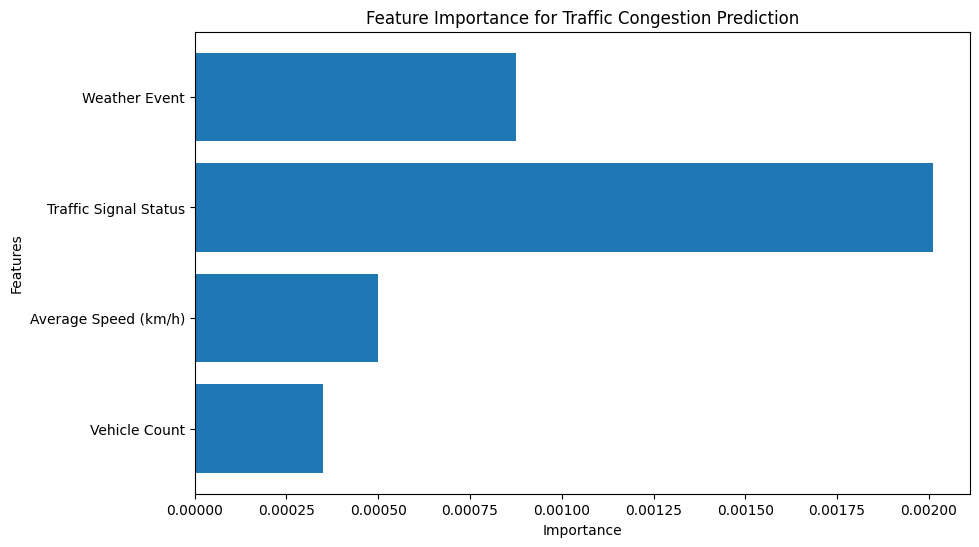

In [15]:

# Visualizing feature importance using a simple bar plot
# Since SVM doesn't provide direct feature importance, we can plot correlation of features with the target.
feature_importance = np.abs(svm_model_kemacetan.coef_.flatten())
plt.figure(figsize=(10, 6))
plt.barh(X.columns, feature_importance)
plt.title("Feature Importance for Traffic Congestion Prediction")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()



## Keterangan Penting

Notebook ini menggunakan data dummy untuk memprediksi status kemacetan lalu lintas berdasarkan beberapa fitur, seperti jumlah kendaraan, kecepatan rata-rata, dan kondisi cuaca. Agar model ini dapat menghasilkan prediksi yang lebih akurat dan relevan, **kustomisasi lebih lanjut diperlukan**. Beberapa hal yang perlu dipertimbangkan antara lain:

1. **Penyempurnaan Dataset**: Data yang digunakan adalah data dummy yang bersifat acak. Untuk hasil yang lebih baik, dataset harus diisi dengan data kemacetan lalu lintas yang lebih realistis dan sesuai dengan kondisi lokal yang relevan.
   
2. **Penyesuaian Fitur**: Beberapa fitur, seperti jumlah kendaraan, kecepatan rata-rata, atau status sinyal lalu lintas, perlu penyesuaian atau penambahan fitur lain yang lebih berdampak pada prediksi kemacetan.

3. **Parameter Model**: Untuk hasil prediksi yang lebih optimal, Anda dapat menyesuaikan parameter model SVM atau mencoba model lain yang lebih sesuai dengan karakteristik data.

4. **Validasi Model**: Melakukan validasi dengan data nyata dan cross-validation untuk mengevaluasi kinerja model.

Dengan penyesuaian yang tepat, model ini dapat memberikan prediksi kemacetan yang lebih akurat dan bermanfaat untuk mengatur lalu lintas di kota dan meningkatkan mobilitas perkotaan.
